## Week 1 Business Analytics Case Study
### Customer Churn Analysis

**Author:** Ahanonu Immanuel

**Internship:** AnalystLab Africa Data Analytics Internship Program  

**Dataset:** Telco Customer Churn Dataset


**Business Problem**

Customer churn is a major challenge in the telecommunications industry because losing existing customers directly affects revenue and increases the cost of acquiring new ones. This project aims to identify the key factors influencing customer churn and provide data-driven recommendations to help the company improve customer retention and make informed business decisions.


**Objective**

The objective of this analysis is to examine customer churn patterns within a telecommunications company, identify the key factors that influences customer attrition, and segment customers based on their churn behavior. Through exploratory data analysis and visualization, the study aims to generate practical business insights and recommend data-driven strategies that can improve customer retention and also support informed decision-making.


###

### **Data Loading and Inspection**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option("display.max_columns", None)

# Display numbers neatly
pd.set_option("display.float_format", "{:.2f}".format)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('Churn_data.csv')

df.head() # data overview for the first 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("""The dataset contains 7,043 customer records described by 21 variables, providing information about customer demographics, subscribed services, 
billing details, and churn status. 
""")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

The dataset contains 7,043 customer records described by 21 variables, providing information about customer demographics, subscribed services, 
billing details, and churn status. 

Rows: 7043
Columns: 21


In [5]:
print("""The columns and their data types, as well as the number of non-null values in each column
""")

df.info()

The columns and their data types, as well as the number of non-null values in each column

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract 

In [6]:
pd.DataFrame(df.nunique().sort_values(ascending=False), columns=['Unique Values'])

,Unique Values
customerID,7043
TotalCharges,6531
MonthlyCharges,1585
tenure,73
PaymentMethod,4
StreamingMovies,3
TechSupport,3
OnlineBackup,3
StreamingTV,3
DeviceProtection,3


In [7]:
missing_values = df.isnull().sum()

pd.DataFrame({'Missing Count': missing_values})

,Missing Count
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [9]:
summary_statistics = df.describe().transpose()

summary_statistics

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75


##### Inspecting some categorical variables

In [10]:
pd.DataFrame(df["gender"].value_counts())

,count
gender,
Male,3555
Female,3488


In [11]:
pd.DataFrame(df["SeniorCitizen"].value_counts())

,count
SeniorCitizen,
0,5901
1,1142


In [12]:
pd.DataFrame(df["Partner"].value_counts())

,count
Partner,
No,3641
Yes,3402


In [13]:
pd.DataFrame(df["Dependents"].value_counts())

,count
Dependents,
No,4933
Yes,2110


In [14]:
df_clean = df.copy()  # Create a copy of the original DataFrame for cleaning and analysis

#### **Data Cleaning**

In [15]:
pd.DataFrame(df_clean["PaymentMethod"].value_counts())

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [16]:
# Removing the word "automatic"

df_clean["PaymentMethod"] = df_clean["PaymentMethod"].replace({"Bank transfer (automatic)": "Bank transfer", 
                                                               "Credit card (automatic)": "Credit card"
})

In [17]:
pd.DataFrame(df_clean["PaymentMethod"].value_counts())

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer,1544
Credit card,1522


In [18]:
# Since this TotalCharges column contains monetary values, it should be numeric. Instead of checking for Nan, check for blank values 

(df_clean["TotalCharges"] == " ").sum() # Count the number of blank values in the TotalCharges column

np.int64(11)

In [19]:
print("""Rows that have blank values in the TotalCharges column have the tenure value to be 0, which means they are new customers. We can replace the 
blank values with 0 and convert the column to numeric.
""")

df_clean[df_clean["TotalCharges"] == " "].head()

Rows that have blank values in the TotalCharges column have the tenure value to be 0, which means they are new customers. We can replace the 
blank values with 0 and convert the column to numeric.



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer,52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card,56.05,,No


In [20]:
print("""Converting the TotalCharges column to numeric...""")

df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors='coerce') 

Converting the TotalCharges column to numeric...


In [21]:
print("""The TotalCharges column has been successfully converted to numeric. Any blank values have been replaced with NaN, which can be handled 
appropriately in further analysis.
""")

df_clean["TotalCharges"].dtype # checking the data type after conversion

The TotalCharges column has been successfully converted to numeric. Any blank values have been replaced with NaN, which can be handled 
appropriately in further analysis.



dtype('float64')

In [22]:
print("""There are now 11 NaN values in the TotalCharges column after conversion.
""")

before = df_clean["TotalCharges"].isnull().sum() # Check for any NaN values after conversion

df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0) # Fill NaN values with 0

after = df_clean["TotalCharges"].isnull().sum() # Check for any NaN values after filling with 0


print(f"Missing values before filling: {before}")
print(f"Missing values after filling: {after}")

There are now 11 NaN values in the TotalCharges column after conversion.

Missing values before filling: 11
Missing values after filling: 0


In [23]:
df_clean["TotalCharges"].info() #checking the data types of the TotalCharges columns after cleaning

<class 'pandas.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [24]:
df_clean.describe().transpose() # checking the summary statistics after cleaning

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.00,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80


In [25]:
## df_clean.to_csv("Churn_Cleaned_Data.csv", index=False) # Save the cleaned DataFrame to a new CSV file

###

### Exploratory Data Analysis for Answering Business Questions

Exploratory Data Analysis (EDA) is performed to understand customer behaviour, identify trends and patterns, and uncover the key factors influencing customer churn. The insights obtained from this analysis will guide the buisness recommendations provided at the end of the study.
The analysis includes both univariate and bivariate analyses to identify patterns, trends, and relationships within the data.

##### **Churn Distribution**

In [26]:
def summary_table(df, column): # a helper function for calculating distribution of categorical variables
    
    summary = (df[column].value_counts().rename("Count").to_frame())

    summary["Percentage"] = (summary["Count"] / summary["Count"].sum() * 100).round(2).astype(str) + "%"

    return summary

summary_table(df_clean, "Churn")

,Count,Percentage
Churn,,
No,5174,73.46%
Yes,1869,26.54%


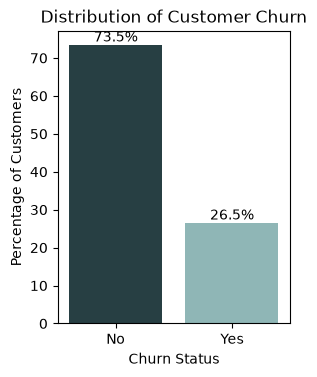

In [27]:
churn_pct = (df_clean["Churn"].value_counts(normalize=True).mul(100).reset_index())

churn_pct.columns = ["Churn", "Percentage"]

plt.figure(figsize=(3, 3.8))

teal_palette = ["#224248", "#88BDBC"]

ax = sns.barplot(
    data=churn_pct,
    x="Churn",
    y="Percentage",
    hue="Churn",
    palette=teal_palette,
    legend=False
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Percentage of Customers")

plt.show()

**Approximately 73.5% of customers remain with the company, while 26.5% have churned. Although customer retention is higher than customer attrition, the churn rate indicates that more than one in every four customers has discontinued the service. This highlights customer churn as a significant business concern and justifies further investigation into the factors driving customer departures.**

##### **Monthly Revenue Lost**

In [28]:
df_clean[df_clean['Churn'] == 'Yes']['MonthlyCharges'].sum() # Total Monthly Charges for customers who churned

np.float64(139130.85)

Over $139k in revenue lost due to customer attrition

##### Correlation Heatmap of few select variables

In [29]:
from sklearn.preprocessing import LabelEncoder

# Select relevant columns
selected_cols = [
    "Churn",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "TechSupport"
]

# Create a copy
corr_df = df_clean[selected_cols].copy()

# Encode categorical variables
le = LabelEncoder()

for col in corr_df.select_dtypes(include="object").columns:
    corr_df[col] = le.fit_transform(corr_df[col])

# Correlation matrix
corr_matrix = corr_df.corr()

In [30]:
corr_df.head()

,Churn,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Partner,Dependents,TechSupport
0,0,1,29.85,29.85,0,1,0,0
1,0,34,56.95,1889.50,0,0,0,0
2,1,2,53.85,108.15,0,0,0,0
3,0,45,42.30,1840.75,0,0,0,2
4,1,2,70.70,151.65,0,0,0,0


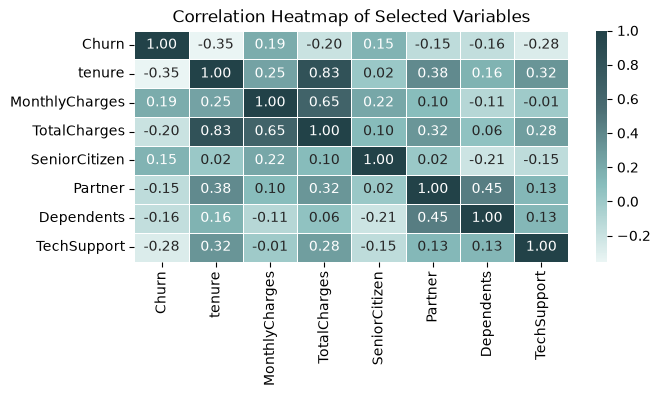

In [31]:
from matplotlib.colors import LinearSegmentedColormap

teal_cmap = LinearSegmentedColormap.from_list(
    "teal_cmap",
    ["#EAF5F4", "#88BDBC", "#4A6C72", "#224248"]
)

plt.figure(figsize=(7,3))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=teal_cmap,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Selected Variables")
plt.show()

**The correlation heatmap indicates that tenure has the strongest negative relationship with churn, suggesting that customers who stay longer are less likely to leave. Tech Support also shows a moderate negative correlation with churn, while Monthly Charges and Senior Citizen status exhibit weak positive correlations. Additionally, Tenure and Total Charges are strongly positively correlated, reflecting that customers with longer tenures naturally accumulate higher total charges. While some variables exhibit moderate correlations, no extremely strong correlations are observed, suggesting that multiple factors collectively influence customer churn**

#### Monthly Charges Distribution

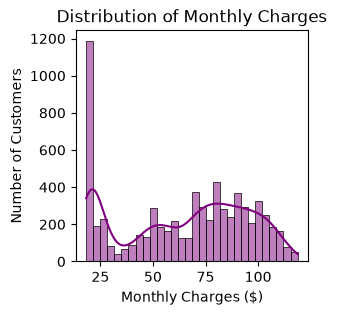

In [32]:
plt.figure(figsize=(3,3))

sns.histplot(
    data=df_clean,
    x="MonthlyCharges",
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")

plt.show()

**The distribution of monthly charges is bimodal, with one concentration of customers on lower-priced plans and another on higher-priced plans. This suggests that the company serves customers across different pricing tiers, likely reflecting variations in the types and combinations of services subscribed to.**

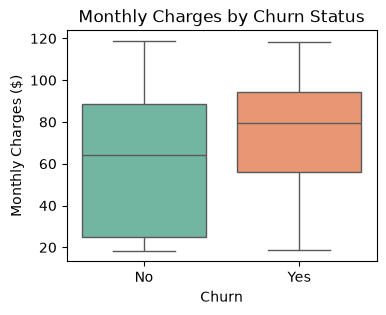

In [33]:
plt.figure(figsize=(4,3))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")

plt.show()

In [34]:
df_clean.groupby("Churn")["MonthlyCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.00,61.27,31.09,18.25,25.10,64.43,88.40,118.75
Yes,1869.00,74.44,24.67,18.85,56.15,79.65,94.20,118.35


**Customers who churn generally have higher monthly charges than those who remain with the company, as indicated by the higher median ($79.65) and interquartile range. In contrast, retained customers exhibit a wider spread of monthly charges, including a large proportion of lower-paying customers. This suggests that higher monthly charges may be associated with an increased likelihood of customer churn.**

#### Senior Citizen vs Churn

In [35]:
senior_churn = (pd.crosstab(df_clean["SeniorCitizen"],df_clean["Churn"],normalize="index") * 100).round(2)

senior_churn.astype(str) + "%"

Churn,No,Yes
SeniorCitizen,,
0,76.39%,23.61%
1,58.32%,41.68%


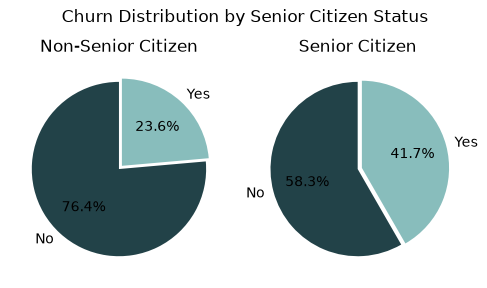

In [57]:
senior_counts = pd.crosstab(df_clean["SeniorCitizen"], df_clean["Churn"])

fig, axes = plt.subplots(1, 2, figsize=(5, 3))

colors = ["#224248",  "#88BDBC"]

for i, status in enumerate(senior_counts.index):
    axes[i].pie(
        senior_counts.loc[status],
        labels=["No", "Yes"],
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        explode=(0, 0.05)
    )

    axes[i].set_title("Non-Senior Citizen" if status == 0 else "Senior Citizen")

plt.suptitle("Churn Distribution by Senior Citizen Status")
plt.tight_layout()

plt.show()

**Non-senior citizens have a relatively low churn rate, with 76.4% remaining with the company and 23.6% churning. In contrast, senior citizens exhibit a substantially higher churn rate, with 41.7% leaving the company compared to 58.3% who remain. This suggests that senior citizens are considerably more likely to churn, indicating the need for targeted retention strategies tailored to this customer segment.**

#### Gender vs Churn

In [58]:
gender_churn = (pd.crosstab(df_clean["gender"],df_clean["Churn"],normalize="index") * 100).round(2)

gender_churn.astype(str) + "%"

Churn,No,Yes
gender,,
Female,73.08%,26.92%
Male,73.84%,26.16%


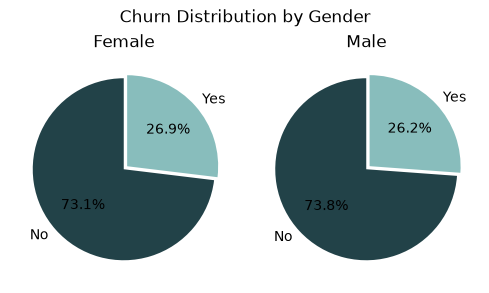

In [64]:
gender_counts = pd.crosstab(df_clean["gender"], df_clean["Churn"])

fig, axes = plt.subplots(1, 2, figsize=(5, 3))

colors = ["#224248", "#88BDBC"]

for i, status in enumerate(gender_counts.index):
    axes[i].pie(
        gender_counts.loc[status],
        labels=["No", "Yes"],
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        explode=(0, 0.05)
    )

    axes[i].set_title(status)

plt.suptitle("Churn Distribution by Gender")
plt.tight_layout()

plt.show()

**Female customers show a churn rate of 26.9%, with 73.1% remaining with the company. Male customers exhibit a nearly identical pattern, with 26.2% churning and 73.8% remaining. This suggests that gender has little to no meaningful effect on churn behavior, indicating that retention strategies are unlikely to need gender-specific tailoring.**

#### Tech Support vs Churn

In [37]:
support_churn = (pd.crosstab(df_clean["TechSupport"],df_clean["Churn"],normalize="index") * 100).round(2)

support_churn.astype(str) + "%"

Churn,No,Yes
TechSupport,,
No,58.36%,41.64%
No internet service,92.6%,7.4%
Yes,84.83%,15.17%


**Customers without tech support show a notably high churn rate, with only 58.36% remaining with the company and 41.64% churning. Those with no internet service exhibit the lowest churn rate by far, with 92.6% staying and just 7.4% leaving, likely reflecting the limited alternatives or different service expectations of this group. Customers who do have tech support fall in between, with 84.83% remaining and 15.17% churning. This suggests that the presence of tech support is associated with meaningfully better retention, and that customers lacking this service are considerably more likely to churn, indicating that expanding tech support adoption could be an effective lever for reducing churn among at-risk segments.**

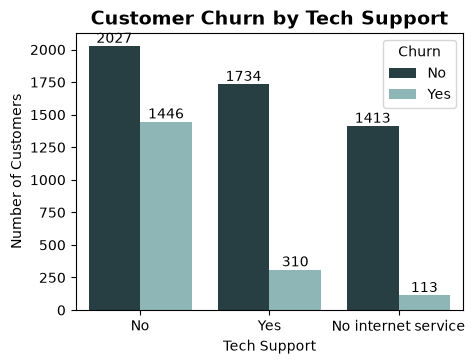

In [38]:
plt.figure(figsize=(5,3.6))

teal_palette = ["#224248", "#88BDBC"]

ax = sns.countplot(
    data=df_clean,
    x='TechSupport',
    hue='Churn',
    palette=teal_palette
)

plt.title('Customer Churn by Tech Support', fontsize=14, fontweight='bold')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

##### **3. Does contract type influence retention?**

In [39]:
summary_table(df_clean, "Contract")

,Count,Percentage
Contract,,
Month-to-month,3875,55.02%
Two year,1695,24.07%
One year,1473,20.91%


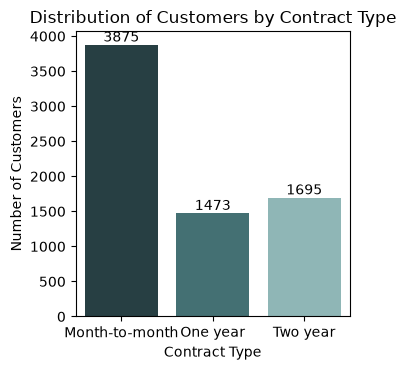

In [40]:
plt.figure(figsize=(3.7, 3.8))

teal_palette = ["#224248", "#3C777B", "#88BDBC"]

ax = sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Contract",
    palette=teal_palette,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Customers by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**The majority of customers are on month-to-month contracts, followed by two-year and one-year contracts. This indicates that most customers prefer flexible, short-term agreements. The high proportion of month-to-month customers suggests that understanding the relationship between contract type and churn is important for developing effective customer retention strategies.**

In [41]:
contract_churn = pd.crosstab(df_clean["Contract"], df_clean["Churn"])

contract_churn # this shows the number of customers in each contract type who stayed or churned

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [42]:
contract_churn_rate = (pd.crosstab(df_clean["Contract"], df_clean["Churn"], normalize="index") * 100).round(2)

contract_churn_rate.astype(str) + "%" # this shows the churn rate and retention rate for each type of contract

Churn,No,Yes
Contract,,
Month-to-month,57.29%,42.71%
One year,88.73%,11.27%
Two year,97.17%,2.83%


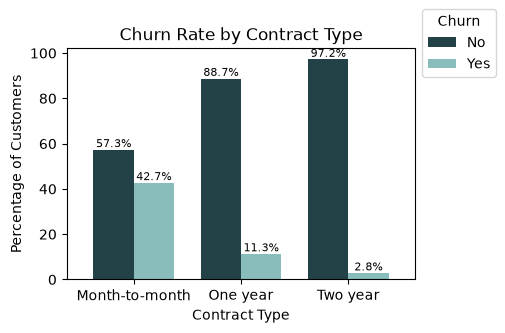

In [43]:
ax = contract_churn_rate.plot(
    kind="bar",
    figsize=(4.5, 3),
    color=["#224248", "#88BDBC"],
    width=0.75
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)

plt.xticks(rotation=0)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.legend(title="Churn", loc="upper right", bbox_to_anchor=(1.25, 1.2))

plt.show()

**Customers on month-to-month contracts exhibit the highest churn rate, while those on one-year and especially two-year contracts have much lower churn rates. This suggests that longer contract commitments are associated with stronger customer retention.**

##### **4. Does tenure affect loyalty?**

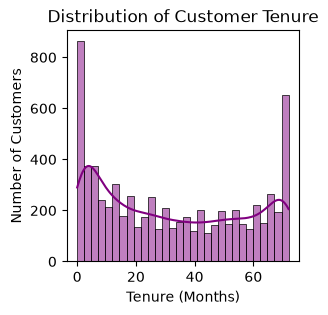

In [44]:
plt.figure(figsize=(3,3))

sns.histplot(
    data=df_clean,
    x="tenure",
    bins=30,
    kde=True, # The KDE line gives a smooth estimate of the distribution and makes it easier to identify where customers are concentrated
    color="purple"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

**The distribution of customer tenure is bimodal, with a large concentration of customers at both the lower and higher ends of the tenure range. This indicates that the company has a substantial number of newly acquired customers as well as many long-term customers, while relatively fewer customers fall within the middle tenure range. This pattern suggests opportunities to investigate whether customer retention differs between new and established customers**

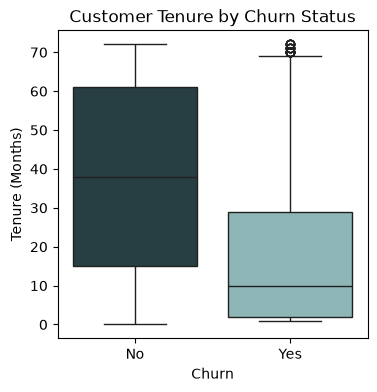

In [45]:
plt.figure(figsize=(4,4))

teal_palette = ["#224248", "#88BDBC"]

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="tenure",
    hue="Churn",
    palette=teal_palette,
    legend=False
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [46]:
df_clean.groupby("Churn")["tenure"].describe().round(2) # gives the mean, median, quartiles, and other statistics for churned and retained customers

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.00,37.57,24.11,0.00,15.00,38.00,61.00,72.00
Yes,1869.00,17.98,19.53,1.00,2.00,10.00,29.00,72.00


**Customers who remained with the company generally have much longer tenures than those who churned. The median tenure for retained customers is considerably higher (38 months), indicating that long-term customers are more likely to stay. In contrast, customers who churn tend to leave within the earlier months (median of 10 months) of their relationship with the company, although a few long-tenure customers also churn, as shown by the outliers. Overall, the analysis suggests a strong relationship between tenure and customer retention, with longer-tenured customers exhibiting greater loyalty**

##### **5. Which services influence churn?**

In [47]:
summary_table(df_clean, "InternetService")

,Count,Percentage
InternetService,,
Fiber optic,3096,43.96%
DSL,2421,34.37%
No,1526,21.67%


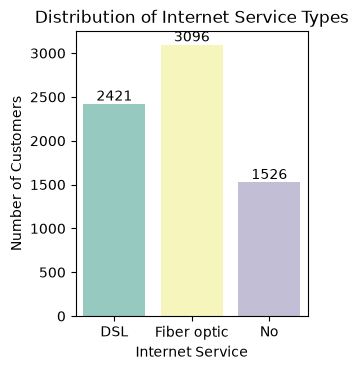

In [48]:
plt.figure(figsize=(3,3.7))

ax = sns.countplot(
    data=df_clean,
    x="InternetService",
    hue="InternetService",
    palette="Set3",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Internet Service Types")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

**The majority of customers subscribe to either Fiber Optic or DSL internet services, while a smaller proportion do not use the company's internet service. This indicates that internet connectivity is a core offering and should be examined further to determine whether the type of internet service influences customer churn.**

In [49]:
internet_churn = (pd.crosstab(df_clean["InternetService"], df_clean["Churn"], normalize="index") * 100).round(2)

internet_churn.astype(str) + "%" # this shows the churn rate and retention rate for each type of internet service

Churn,No,Yes
InternetService,,
DSL,81.04%,18.96%
Fiber optic,58.11%,41.89%
No,92.6%,7.4%


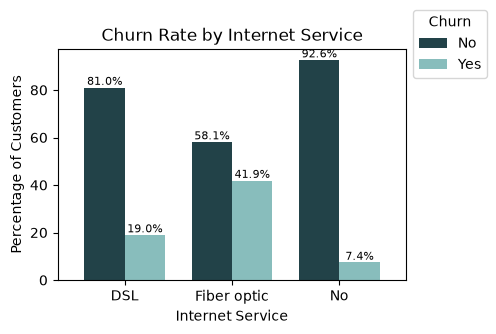

In [50]:
ax = internet_churn.plot(
    kind="bar",
    figsize=(4.5, 3),
    color=["#224248", "#88BDBC"],
    width=0.75
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)

plt.xticks(rotation=0)
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.legend(title="Churn", loc="upper right", bbox_to_anchor=(1.25, 1.2))

plt.show()

**Customers using Fiber Optic internet exhibit a noticeably higher churn rate (more than double the rate of DSL Customers) than those using DSL or those without internet service. This suggests that customers on Fiber Optic plans may be experiencing issues such as higher costs, unmet service expectations, or quality concerns. Further investigation into the customer experience for Fiber Optic users may help reduce churn.**

##### **6. Which payment methods have higher churn?**

In [51]:
summary_table(df_clean, "PaymentMethod")

,Count,Percentage
PaymentMethod,,
Electronic check,2365,33.58%
Mailed check,1612,22.89%
Bank transfer,1544,21.92%
Credit card,1522,21.61%


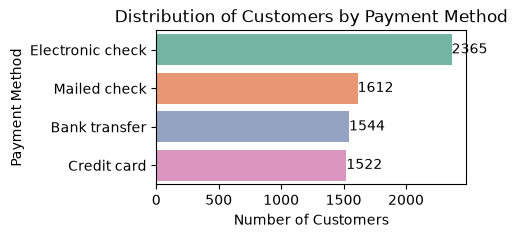

In [52]:
plt.figure(figsize=(4,2))

ax = sns.countplot(
    data=df_clean,
    y="PaymentMethod",
    hue="PaymentMethod",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Customers by Payment Method")
plt.xlabel("Number of Customers")
plt.ylabel("Payment Method")

plt.show()

**Electronic check is the most commonly used payment method, accounting for 2,365 customers, followed by Mailed check (1,612), Bank transfer (1,544), and Credit card (1,522). While customers use a variety of payment methods, electronic check is the preferred option among the customer base. This distribution provides a basis for investigating whether certain payment methods are associated with higher customer churn.**

In [53]:
payment_churn = (pd.crosstab(df_clean["PaymentMethod"], df_clean["Churn"], normalize="index") * 100).round(2)

payment_churn.astype(str) + "%"

Churn,No,Yes
PaymentMethod,,
Bank transfer,83.29%,16.71%
Credit card,84.76%,15.24%
Electronic check,54.71%,45.29%
Mailed check,80.89%,19.11%


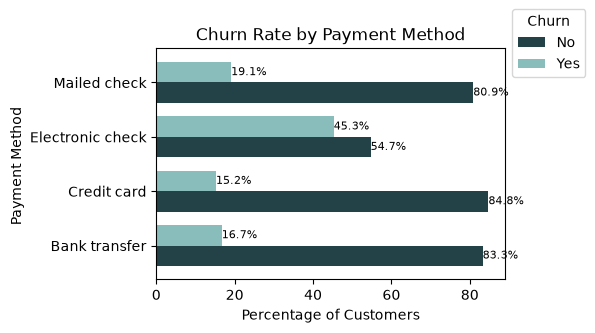

In [54]:
ax = payment_churn.plot(
    kind="barh",
    figsize=(4.5, 3),
    color=["#224248", "#88BDBC"],
    width=0.75
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)

plt.xticks(rotation=0)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Percentage of Customers")
plt.ylabel("Payment Method ")
plt.legend(title="Churn", loc="upper right", bbox_to_anchor=(1.25, 1.2))

plt.show()

**The churn rate varies noticeably across payment methods. Customers who pay via Electronic check exhibit the highest churn rate, with nearly half of these customers leaving the company. In contrast, customers using Bank transfer and Credit card experience the lowest churn rates, while Mailed check customers show a moderate level of churn. These findings suggest that payment method is associated with customer retention, and promoting automatic or more convenient payment options may help reduce churn.**

##### ***Drill Down(Segment) Analysis***

Analyzing customer churn by month-to-month contract, payment and internet service

In [55]:
# Filtering for Month-to-month customers
month_to_month = df_clean[df_clean["Contract"] == "Month-to-month"]

# Calculating churn rate for each Payment Method and Internet Service combination
plot_data = (
    month_to_month
    .groupby(["PaymentMethod", "InternetService"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plot_data

,PaymentMethod,InternetService,ChurnRate
0,Bank transfer,DSL,19.80
1,Bank transfer,Fiber optic,45.57
2,Bank transfer,No,20.00
3,Credit card,DSL,27.03
4,Credit card,Fiber optic,41.64
5,Credit card,No,9.23
6,Electronic check,DSL,40.51
7,Electronic check,Fiber optic,60.37
8,Electronic check,No,18.84
9,Mailed check,DSL,30.79


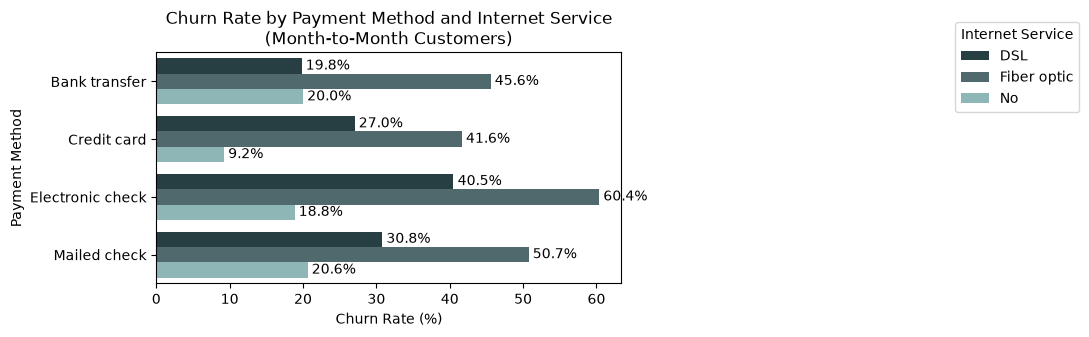

In [56]:
plt.figure(figsize=(6, 3))

teal_palette = [
    "#224248",  # Dark teal
    "#4A6C72",  # Medium teal
    "#88BDBC"   # Light teal
]

sns.barplot(
    data=plot_data,
    x="ChurnRate",
    y="PaymentMethod",
    hue="InternetService",
    palette=teal_palette
)

plt.title("Churn Rate by Payment Method and Internet Service\n(Month-to-Month Customers)")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

# Add percentage labels
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.1f%%", padding=3)

plt.legend(title="Internet Service", loc="upper right", bbox_to_anchor=(2, 1.16))
plt.tight_layout()
plt.show()

The combined analysis of month-to-month contract type, payment method, and internet service reveals that customers on ***month-to-month*** contracts who use ***Fiber Optic internet*** and pay via ***Electronic Check*** exhibit the highest churn rate ***(60.37%)***. High churn is also observed among month-to-month Fiber Optic customers using Mailed Check (50.75%) and Bank Transfer (45.57%). These findings suggest that contract type remains the strongest determinant of retention, while Fiber Optic service and Electronic Check further increase churn risk within the month-to-month customer segment

##### **1. What does the customer base look like?**

The company's customer base consists primarily of non-senior citizens, with most customers subscribing to month-to-month contracts. Fiber Optic and DSL are the dominant internet service types, while Electronic Check is the most commonly used payment method. The customer base comprises both newly acquired and long-term customers, as reflected by the bimodal distribution of tenure, and spans a range of pricing tiers based on monthly charges

#### **2. Which segments have the highest churn?**

The analysis identified several customer segments with distinct churn behaviors. Customers on month-to-month contracts, Fiber Optic internet plans, and those paying via Electronic Check exhibit the highest churn rates. Customers with shorter tenures, higher monthly charges, and without Tech Support are also more likely to churn. Additionally, senior citizens experience higher churn rates than non-senior citizens, while gender has little influence on customer retention.

#### **7. What actions should management take?**

##### **Action 1: Focus on converting month-to-month customers to longer-term contracts** 

*by offering discounts, loyalty rewards, or bundled packages to reduce churn among month-to-month subscribers. Even a modest conversion rate can significantly lower overall churn and protect revenue, since these customers are among the most at risk and often the easiest to retain with the right offer.*

##### **Action 2: Improve Fiber Optic value and reliability** 

*by resolving service quality issues and introducing competitively priced tiers or loyalty bundles to close the retention gap with DSL customers.*

##### **Action 3: Promote automatic payment methods** 

*by encouraging customers who use Electronic Check to switch to bank transfer or credit card payments through incentives and awareness campaigns.*

##### **Action 4: Invest heavily in the first few months of a customer’s journey** 

*by making onboarding more personal and anticipatory through schedule check-ins, offering timely help, and presenting relevant upgrades or loyalty incentives early on.*

##### **Action 5: Increase adoption of value-added services** 

*such as Tech Support and Online Security, through bundled plans and promotional campaigns to improve customer satisfaction and retention.*

##### **Action 6: Build a churn-risk scoring system for early intervention** 

*by combining tenure, contract type, and payment method into a risk score that flags customers before cancellation intent forms, triggering proactive outreach.*